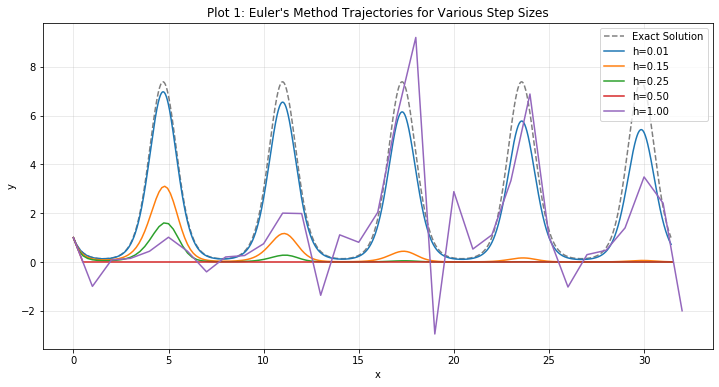

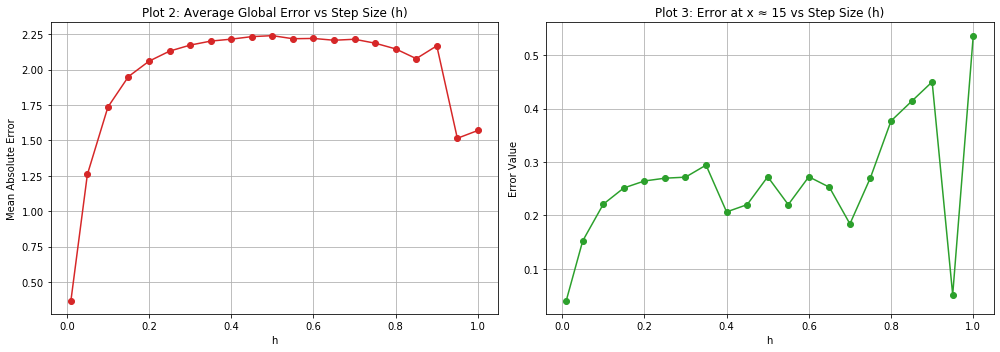

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def f(x, y):
    return -2 * y * np.cos(x)

def exact_sol(x):
    
    return np.exp(-2 * np.sin(x))


x_start, x_end = 0, 10 * np.pi
target_x = 15.0
h_values = [0.01] + list(np.arange(0.05, 1.01, 0.05))


results = []
plot_selection = [0.01, 0.15, 0.25, 0.5, 1.0]

plt.figure(figsize=(12, 6))
x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(x_fine, exact_sol(x_fine), 'k--', label='Exact Solution', alpha=0.5)


for h in h_values:
    steps = int(np.ceil((x_end - x_start) / h))
    x = np.zeros(steps + 1)
    y = np.zeros(steps + 1)
    x[0], y[0] = 0, 1
    
    for i in range(steps):
        y[i+1] = y[i] + h * f(x[i], y[i])
        x[i+1] = x[i] + h
    
    
    y_exact = exact_sol(x)
    abs_errors = np.abs(y_exact - y)
    avg_error = np.mean(abs_errors)
    avg_y = np.mean(y)
    
    
    idx_15 = np.argmin(np.abs(x - target_x))
    err_at_15 = abs_errors[idx_15]
    
    results.append({
        'h': h,
        'avg_y': avg_y,
        'avg_err': avg_error,
        'err_15': err_at_15
    })
    
    
    if any(np.isclose(h, p) for p in plot_selection):
        plt.plot(x, y, label=f'h={h:.2f}')

plt.title("Plot 1: Euler's Method Trajectories for Various Step Sizes")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


h_list = [r['h'] for r in results]
avg_err_list = [r['avg_err'] for r in results]
err_15_list = [r['err_15'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(h_list, avg_err_list, 'o-', color='tab:red')
ax1.set_title("Plot 2: Average Global Error vs Step Size (h)")
ax1.set_xlabel("h")
ax1.set_ylabel("Mean Absolute Error")
ax1.grid(True)


ax2.plot(h_list, err_15_list, 'o-', color='tab:green')
ax2.set_title("Plot 3: Error at x ≈ 15 vs Step Size (h)")
ax2.set_xlabel("h")
ax2.set_ylabel("Error Value")
ax2.grid(True)

plt.tight_layout()
plt.show()

# I see that the accuracy is step-dependent. The method also overshoots peaks and undershoots troughs. 
# The error also compounds, so as h increases so does the error. 